<a href="https://colab.research.google.com/github/jerry-phillips/Capstone-Survey-Existing-Research/blob/main/Scale_Your_Prototype_with_Large_Scale_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# imports
from google.colab import files
import pandas as pd
import numpy as np
import time
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (silhouette_score, f1_score, accuracy_score,
                             classification_report)
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

In [2]:
# pick the file from computer
# link to file https://www.kaggle.com/datasets/jahnavipaliwal/video-game-reviews-and-ratings
uploaded = files.upload()

Saving video_game_reviews.csv to video_game_reviews (8).csv


In [3]:
# Load data
df = pd.read_csv('video_game_reviews.csv')
print(f"Original dataset: {df.shape}")

# --- Preprocessing ---
df_model = df.copy()

# Ordinal Encoding
df_model['Graphics Quality'] = df_model['Graphics Quality'].map({'Low': 0, 'Medium': 1, 'High': 2, 'Ultra': 3})
df_model['Soundtrack Quality'] = df_model['Soundtrack Quality'].map({'Poor': 0, 'Average': 1, 'Good': 2, 'Excellent': 3})
df_model['Story Quality'] = df_model['Story Quality'].map({'Poor': 0, 'Average': 1, 'Good': 2, 'Excellent': 3})
df_model['Age Group Targeted'] = df_model['Age Group Targeted'].map({'Kids': 0, 'Teens': 1, 'All Ages': 2, 'Adults': 3})

# Binary Encoding
df_model['Multiplayer'] = df_model['Multiplayer'].map({'No': 0, 'Yes': 1})
df_model['Game Mode'] = df_model['Game Mode'].map({'Offline': 0, 'Online': 1})

# One-Hot Encoding
df_model = pd.get_dummies(df_model, columns=['Genre', 'Platform'], drop_first=False)

# Drop non-feature columns
drop_cols = ['Game Title', 'Developer', 'Publisher', 'User Review Text', 'Requires Special Device']
df_features = df_model.drop(columns=drop_cols)

# Scale
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_features), columns=df_features.columns)

# Create target for logistic regression
y = (df['User Rating'] > df['User Rating'].median()).astype(int)

print(f"Preprocessed features: {df_scaled.shape}")
print("Setup complete!")

Original dataset: (47774, 18)
Preprocessed features: (47774, 26)
Setup complete!


In [4]:
## Section 2: Generate Scaled Datasets

def scale_dataset(df_scaled, y, target_size):
    """Replicate and add noise to create larger datasets."""
    repeats = int(np.ceil(target_size / len(df_scaled)))

    X_large = pd.DataFrame(
        np.tile(df_scaled.values, (repeats, 1))[:target_size],
        columns=df_scaled.columns
    )
    noise = np.random.normal(0, 0.05, X_large.shape)
    X_large = X_large + noise

    y_large = np.tile(y.values, repeats)[:target_size]

    return X_large, y_large

# Reduced sizes to avoid memory crashes
dataset_sizes = [47774, 250000, 500000, 1000000]
datasets = {}

for size in dataset_sizes:
    if size == 47774:
        datasets[size] = (df_scaled, y.values)
        print(f"Original: {size:>10,} rows")
    else:
        X_large, y_large = scale_dataset(df_scaled, y, size)
        datasets[size] = (X_large, y_large)
        print(f"Generated: {size:>10,} rows | Shape: {X_large.shape}")

print("\nAll datasets ready!")

Original:     47,774 rows
Generated:    250,000 rows | Shape: (250000, 26)
Generated:    500,000 rows | Shape: (500000, 26)
Generated:  1,000,000 rows | Shape: (1000000, 26)

All datasets ready!


K-MEANS vs MINIBATCH K-MEANS SCALING COMPARISON

--- Dataset size: 47,774 rows ---
  KMeans:      0.52s | Silhouette: 0.2335
  MiniBatch:   0.12s | Silhouette: 0.2335

--- Dataset size: 250,000 rows ---
  KMeans:      2.08s | Silhouette: 0.2316
  MiniBatch:   0.31s | Silhouette: 0.1850

--- Dataset size: 500,000 rows ---
  KMeans:      4.94s | Silhouette: 0.2321
  MiniBatch:   0.68s | Silhouette: 0.2321

--- Dataset size: 1,000,000 rows ---
  KMeans:      6.63s | Silhouette: 0.2318
  MiniBatch:   1.07s | Silhouette: 0.2318


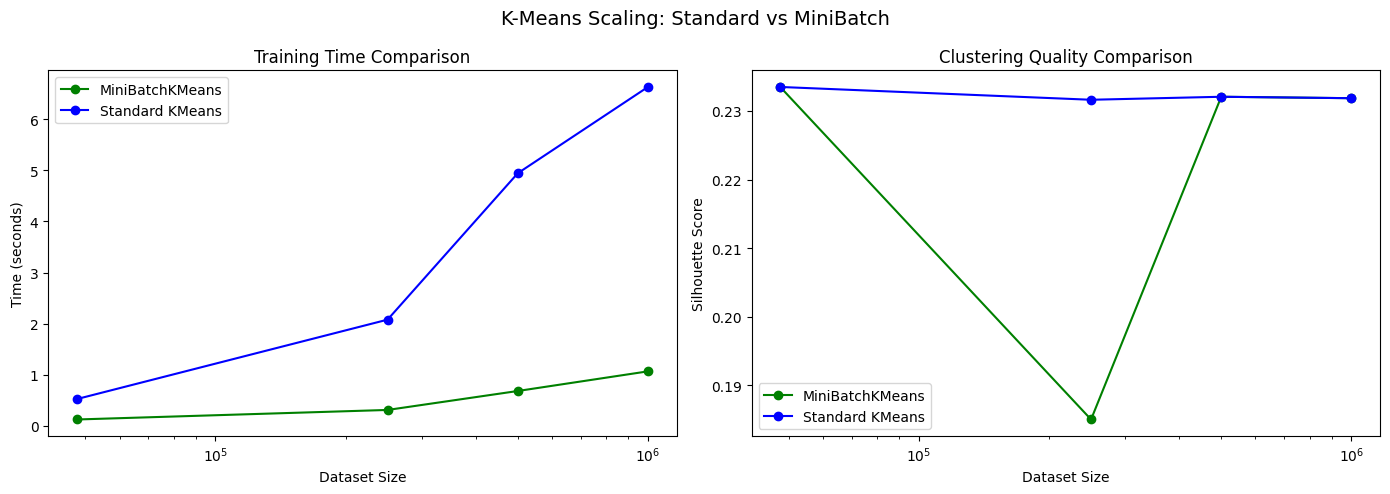

In [5]:
## Section 3: K-Means vs MiniBatchKMeans Scaling Comparison

print("=" * 70)
print("K-MEANS vs MINIBATCH K-MEANS SCALING COMPARISON")
print("=" * 70)

kmeans_results = []

for size in dataset_sizes:
    X, _ = datasets[size]
    print(f"\n--- Dataset size: {size:,} rows ---")

    # Standard KMeans (skip for 5M — too slow)
    if size <= 1000000:
        start = time.time()
        km = KMeans(n_clusters=10, random_state=42, n_init=5)
        km_labels = km.fit_predict(X)
        km_time = time.time() - start
        km_sil = silhouette_score(X, km_labels, sample_size=5000, random_state=42)
        print(f"  KMeans:      {km_time:.2f}s | Silhouette: {km_sil:.4f}")
    else:
        km_time = None
        km_sil = None
        print(f"  KMeans:      SKIPPED (too large)")

    # MiniBatchKMeans
    start = time.time()
    mbk = MiniBatchKMeans(n_clusters=10, random_state=42, batch_size=1024, n_init=5)
    mbk_labels = mbk.fit_predict(X)
    mbk_time = time.time() - start
    mbk_sil = silhouette_score(X, mbk_labels, sample_size=5000, random_state=42)
    print(f"  MiniBatch:   {mbk_time:.2f}s | Silhouette: {mbk_sil:.4f}")

    kmeans_results.append({
        'size': size,
        'kmeans_time': km_time,
        'kmeans_silhouette': km_sil,
        'minibatch_time': mbk_time,
        'minibatch_silhouette': mbk_sil
    })

# Plot comparison
results_km = pd.DataFrame(kmeans_results)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Time comparison
ax1.plot(results_km['size'], results_km['minibatch_time'], 'go-', label='MiniBatchKMeans')
km_valid = results_km.dropna(subset=['kmeans_time'])
ax1.plot(km_valid['size'], km_valid['kmeans_time'], 'bo-', label='Standard KMeans')
ax1.set_xlabel('Dataset Size')
ax1.set_ylabel('Time (seconds)')
ax1.set_title('Training Time Comparison')
ax1.legend()
ax1.set_xscale('log')

# Silhouette comparison
ax2.plot(results_km['size'], results_km['minibatch_silhouette'], 'go-', label='MiniBatchKMeans')
ax2.plot(km_valid['size'], km_valid['kmeans_silhouette'], 'bo-', label='Standard KMeans')
ax2.set_xlabel('Dataset Size')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Clustering Quality Comparison')
ax2.legend()
ax2.set_xscale('log')

plt.suptitle('K-Means Scaling: Standard vs MiniBatch', fontsize=14)
plt.tight_layout()
plt.show()

In [6]:
# Free memory from Section 2 datasets
if 'datasets' in dir():
    del datasets
import gc
gc.collect()

2161

In [ ]:
## Section 4: Cosine Similarity Scaling

import gc

print("=" * 70)
print("COSINE SIMILARITY SCALING COMPARISON")
print("=" * 70)
print("Comparing: Full Matrix vs On-Demand (single game lookup)")

cosine_results = []
cosine_sizes = [47774, 100000, 250000, 500000]

# Use the original scaled data as our base
base_X = df_scaled.values

for size in cosine_sizes:
    print(f"\n--- Dataset size: {size:,} rows ---")

    # Generate data for this size only
    if size == 47774:
        X_np = base_X.copy()
    else:
        repeats = int(np.ceil(size / len(base_X)))
        X_np = np.tile(base_X, (repeats, 1))[:size]
        X_np = X_np + np.random.normal(0, 0.05, X_np.shape)

    # Full matrix — only for original size
    if size <= 47774:
        start = time.time()
        full_matrix = cosine_similarity(X_np)
        full_time = time.time() - start
        print(f"  Full Matrix:  {full_time:.2f}s | Matrix shape: {full_matrix.shape}")
        del full_matrix
        gc.collect()
    else:
        full_time = None
        mem_needed = size**2 * 8 / 1e9
        print(f"  Full Matrix:  SKIPPED (would require {mem_needed:.1f} GB)")

    # On-demand: 10 lookups
    start = time.time()
    sample_indices = np.random.choice(len(X_np), size=10, replace=False)
    avg_sim_scores = []

    for idx in sample_indices:
        sim_scores = cosine_similarity(X_np[idx].reshape(1, -1), X_np)[0]
        top_5 = np.sort(sim_scores)[-6:-1]
        avg_sim_scores.append(top_5.mean())

    demand_time = time.time() - start
    avg_similarity = np.mean(avg_sim_scores)
    print(f"  On-Demand:    {demand_time:.2f}s (10 lookups) | Avg Similarity: {avg_similarity:.4f}")

    cosine_results.append({
        'size': size,
        'full_matrix_time': full_time,
        'on_demand_time': demand_time,
        'avg_similarity': avg_similarity
    })

    # Free memory before next iteration
    del X_np
    gc.collect()

# Plot
results_cos = pd.DataFrame(cosine_results)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(results_cos['size'], results_cos['on_demand_time'], 'ro-')
ax1.set_xlabel('Dataset Size')
ax1.set_ylabel('Time (seconds)')
ax1.set_title('Cosine Similarity: On-Demand Lookup Time')
ax1.set_xscale('log')

ax2.plot(results_cos['size'], results_cos['avg_similarity'], 'ro-')
ax2.set_xlabel('Dataset Size')
ax2.set_ylabel('Average Top-5 Similarity')
ax2.set_title('Recommendation Quality at Scale')
ax2.set_xscale('log')

plt.suptitle('Cosine Similarity Scaling Analysis', fontsize=14)
plt.tight_layout()
plt.show()

COSINE SIMILARITY SCALING COMPARISON
Comparing: Full Matrix vs On-Demand (single game lookup)

--- Dataset size: 47,774 rows ---


In [ ]:
## Section 5: Logistic Regression vs SGDClassifier Scaling

print("=" * 70)
print("LOGISTIC REGRESSION vs SGD CLASSIFIER SCALING COMPARISON")
print("=" * 70)

lr_results = []

for size in dataset_sizes:
    X, y_data = datasets[size]
    print(f"\n--- Dataset size: {size:,} rows ---")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y_data, test_size=0.2, random_state=42, stratify=y_data
    )

    # Standard Logistic Regression (skip for 5M)
    if size <= 1000000:
        start = time.time()
        lr = LogisticRegression(random_state=42, max_iter=1000)
        lr.fit(X_train, y_train)
        lr_time = time.time() - start
        lr_pred = lr.predict(X_test)
        lr_f1 = f1_score(y_test, lr_pred)
        lr_acc = accuracy_score(y_test, lr_pred)
        print(f"  LogisticReg:  {lr_time:.2f}s | Accuracy: {lr_acc:.4f} | F1: {lr_f1:.4f}")
    else:
        lr_time = None
        lr_f1 = None
        lr_acc = None
        print(f"  LogisticReg:  SKIPPED (too large)")

    # SGD Classifier
    start = time.time()
    sgd = SGDClassifier(loss='log_loss', random_state=42, max_iter=1000, tol=1e-3)
    sgd.fit(X_train, y_train)
    sgd_time = time.time() - start
    sgd_pred = sgd.predict(X_test)
    sgd_f1 = f1_score(y_test, sgd_pred)
    sgd_acc = accuracy_score(y_test, sgd_pred)
    print(f"  SGD:          {sgd_time:.2f}s | Accuracy: {sgd_acc:.4f} | F1: {sgd_f1:.4f}")

    lr_results.append({
        'size': size,
        'lr_time': lr_time, 'lr_f1': lr_f1, 'lr_accuracy': lr_acc,
        'sgd_time': sgd_time, 'sgd_f1': sgd_f1, 'sgd_accuracy': sgd_acc
    })

# Plot comparison
results_lr = pd.DataFrame(lr_results)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Time comparison
ax1.plot(results_lr['size'], results_lr['sgd_time'], 'go-', label='SGDClassifier')
lr_valid = results_lr.dropna(subset=['lr_time'])
ax1.plot(lr_valid['size'], lr_valid['lr_time'], 'bo-', label='LogisticRegression')
ax1.set_xlabel('Dataset Size')
ax1.set_ylabel('Time (seconds)')
ax1.set_title('Training Time Comparison')
ax1.legend()
ax1.set_xscale('log')

# F1 comparison
ax2.plot(results_lr['size'], results_lr['sgd_f1'], 'go-', label='SGDClassifier')
ax2.plot(lr_valid['size'], lr_valid['lr_f1'], 'bo-', label='LogisticRegression')
ax2.set_xlabel('Dataset Size')
ax2.set_ylabel('F1 Score')
ax2.set_title('Model Quality Comparison')
ax2.legend()
ax2.set_xscale('log')

plt.suptitle('Logistic Regression Scaling: Standard vs SGD', fontsize=14)
plt.tight_layout()
plt.show()